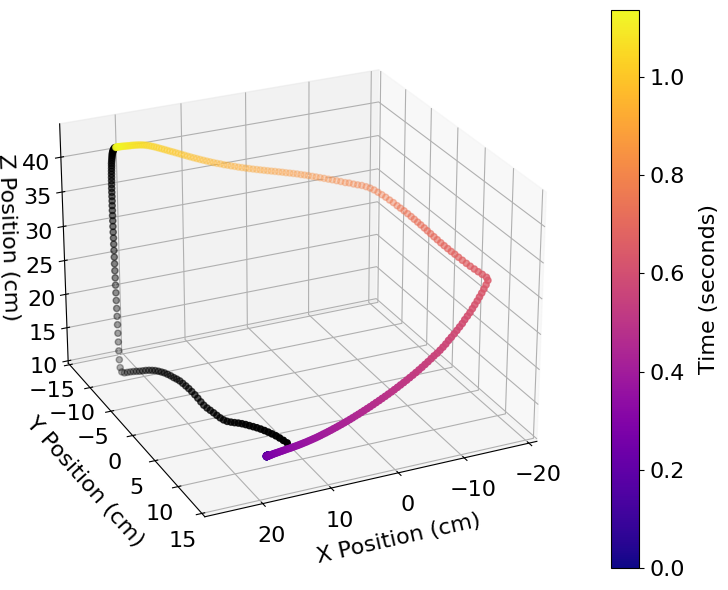

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # for 3D plotting

# === Load the Data ===
test4 = "https://docs.google.com/spreadsheets/d/e/2PACX-1vRaRzn3p7DEx40Gsx_D0ltaw6VG2lRd4NGwUobg2threpUJBXDHIhoYxcgwhWeQA3Gpf5CBD0eu4FiE/pub?gid=0&single=true&output=csv"
df = pd.read_csv(test4)

# === Create a 3D Plot of the Asset's Movement ===
fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection='3d')

# Plot the trajectory using X, Y, Z columns (line for overall path)
ax.plot(df['X - position'], df['Y - position'], df['Z - position'],
        linewidth=1, color='white', zorder=1)

# Create a time axis based on 240 FPS
FPS = 240
t = np.linspace(0, len(df) / FPS, len(df))  # time in seconds

# Choose a colormap for the time-based coloring
cmap = plt.cm.plasma  # options: plasma, viridis, inferno, magma, etc.

# Create masks for motor on and motor off points
mask_before_2 = t < 1.14
mask_after_2 = t >= 1.14

# Plot scatter for points before 2 seconds using the colormap
sc1 = ax.scatter(df.loc[mask_before_2, 'X - position'],
                 df.loc[mask_before_2, 'Y - position'],
                 df.loc[mask_before_2, 'Z - position'],
                 c=t[mask_before_2], cmap=cmap, marker='o', zorder=3) # , label='Motors on'

# Plot scatter for points after 2 seconds using a constant color (e.g., red)
sc2 = ax.scatter(df.loc[mask_after_2, 'X - position'],
                 df.loc[mask_after_2, 'Y - position'],
                 df.loc[mask_after_2, 'Z - position'],
                 color='black', marker='o', zorder=3, label='Motors turned off')

# Add a colorbar for the colormap-based points
cbar = plt.colorbar(sc1, ax=ax, label='Time (seconds)')
cbar.ax.tick_params(labelsize=16)
cbar.set_label('Time (seconds)', fontsize=16, labelpad=10)

# Adjust the viewing angle (elevation and azimuth)
ax.view_init(elev=25, azim=65)

# Set plot titles and labels
#ax.set_title('3D Asset Movement over Time')
ax.tick_params(labelsize=16)
ax.set_xlabel('X Position (cm)', fontsize=16, labelpad=10)
ax.set_ylabel('Y Position (cm)', fontsize=16, labelpad=10)
ax.set_zlabel('Z Position (cm)', fontsize=16, labelpad=5)
#ax.legend()
plt.tight_layout()
plt.show()

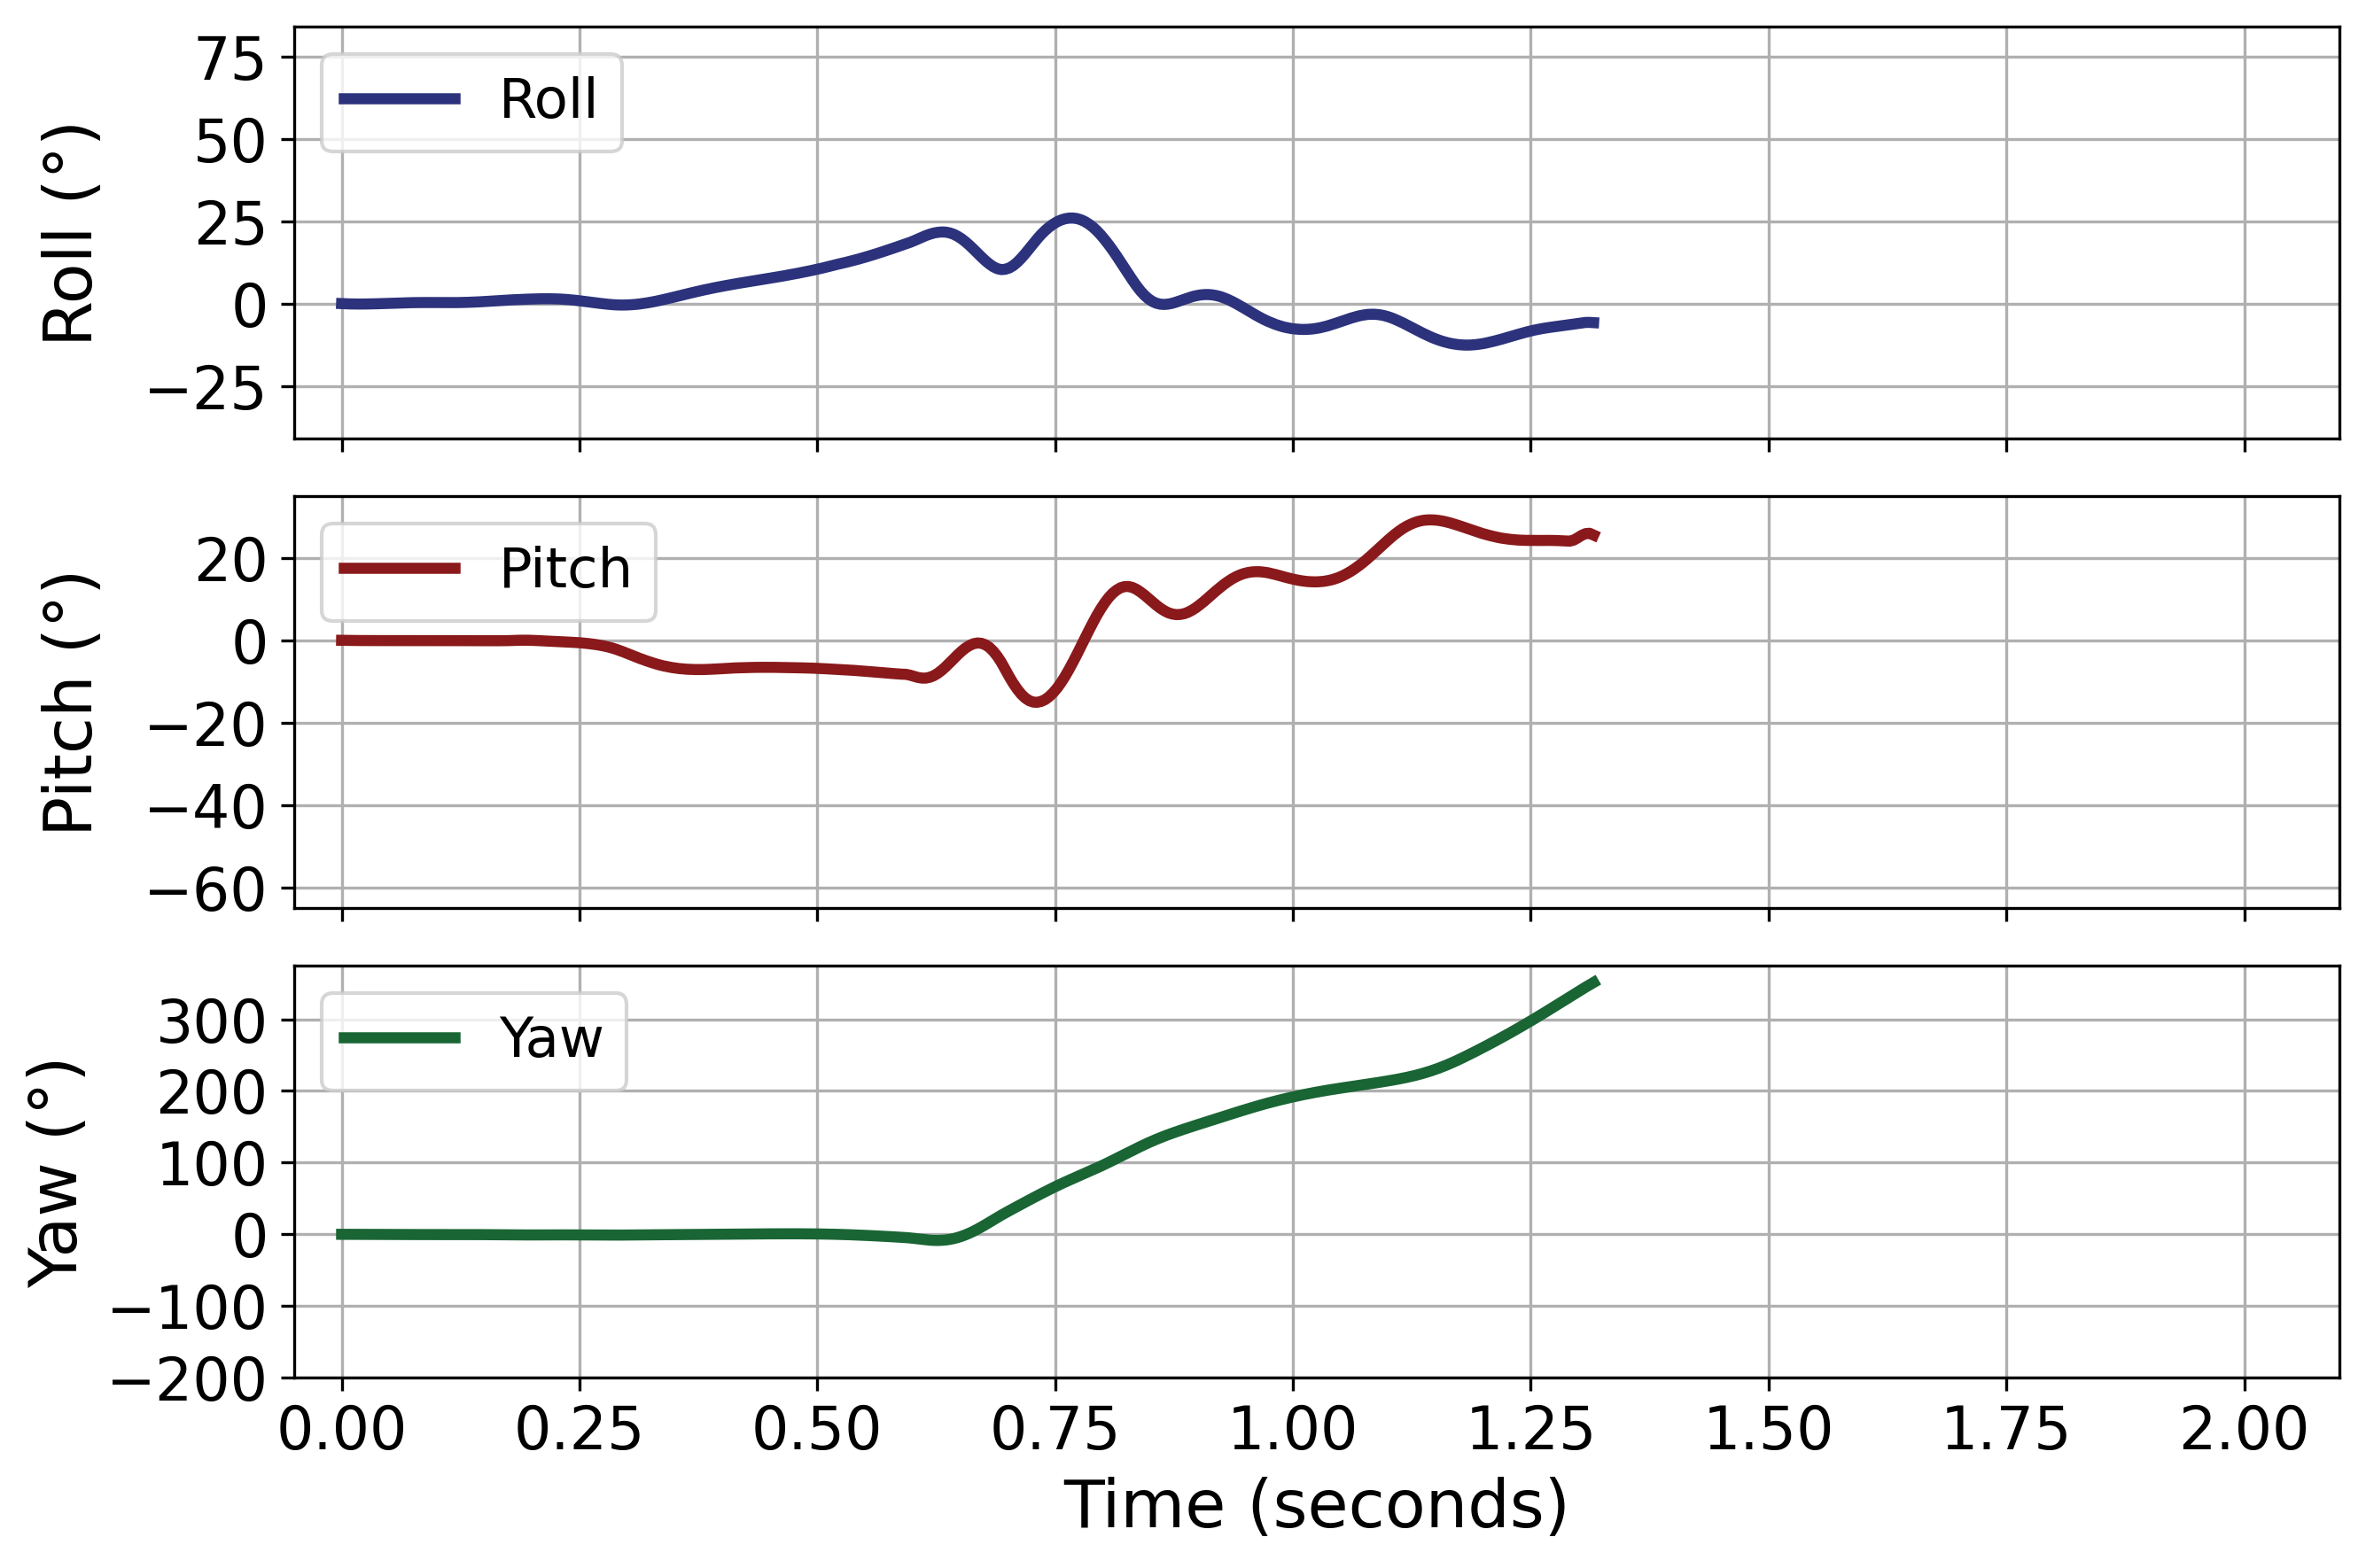

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, find_peaks
import math

# === Global Constants ===
G_PROMINENCE = 0.05
G_DISTANCE = 100
G_AXIS = 'Roll'
G_VIEW = 1000
FPS = 240

# === Data Start Variable ===
# Set this to a custom starting index, or use None to auto-detect the start.
data_start = None  # e.g., data_start = 84

# === Y-Axis Displacement Variables ===
roll_disp = 0      # Displacement for Roll (in degrees)
pitch_disp = 0      # Displacement for Pitch (in degrees)
yaw_disp = 0       # Displacement for Yaw (in degrees)

# === Helper Functions ===
def toDegrees(rad):
    return rad * 180 / math.pi

def euler_from_quaternion(x, y, z, w):
    """
    Convert a quaternion (x, y, z, w) to Euler angles (roll, pitch, yaw)
    using the Tait-Bryan angles (rotation order ZYX). The angles are returned in degrees.
    """
    # Compute Roll (x-axis rotation)
    sinr_cosp = 2.0 * (w * x + y * z)
    cosr_cosp = 1.0 - 2.0 * (x * x + y * y)
    roll = math.atan2(sinr_cosp, cosr_cosp)

    # Compute Pitch (y-axis rotation)
    sinp = 2.0 * (w * y - z * x)
    # Clamp sinp to the range [-1, 1] to avoid numerical errors.
    if sinp > 1.0:
        sinp = 1.0
    elif sinp < -1.0:
        sinp = -1.0
    pitch = math.asin(sinp)

    # Compute Yaw (z-axis rotation)
    siny_cosp = 2.0 * (w * z + x * y)
    cosy_cosp = 1.0 - 2.0 * (y * y + z * z)
    yaw = math.atan2(siny_cosp, cosy_cosp)

    return math.degrees(roll) * -1, math.degrees(pitch) * 1, math.degrees(yaw) * 1

def smooth_signal(signal, window_length=25, polyorder=3):
    return savgol_filter(signal, window_length, polyorder)

def process_euler(df, custom_start=None):
    # Convert quaternion columns to Euler angles.
    euler_angles = df.apply(
        lambda row: euler_from_quaternion(
            row['X - rotation'], row['Y - rotation'], row['Z - rotation'], row['W - rotation']
        ),
        axis=1
    )
    euler_df = pd.DataFrame(euler_angles.tolist(), columns=['Roll', 'Pitch', 'Yaw'])

    # Smooth each Euler angle signal.
    for axis in ['Roll', 'Pitch']: # , 'Yaw'
        euler_df[axis] = smooth_signal(euler_df[axis])

    # Auto-detect starting index using peaks in the Roll signal.
    peak_indices, _ = find_peaks(euler_df[G_AXIS], height=0, distance=G_DISTANCE, prominence=G_PROMINENCE)
    start_peak_idx = None
    for i in range(1, len(peak_indices)):
        if abs(euler_df[G_AXIS].iloc[peak_indices[i]] - euler_df[G_AXIS].iloc[peak_indices[i - 1]]) > 50:
            start_peak_idx = peak_indices[i - 1]
            break

    if custom_start is not None:
        start = custom_start
    else:
        start = max((start_peak_idx if start_peak_idx is not None else 0), 5)
    end = start + G_VIEW
    return euler_df.iloc[start - 5:end].reset_index(drop=True)

def trim_by_degree_change(euler_df, threshold=10):
    roll = euler_df['Roll'].values
    for i in range(1, len(roll)):
        if abs(roll[i] - roll[i - 1]) < threshold:
            return euler_df.iloc[i:].reset_index(drop=True)
    return euler_df

# === Load and Process a Single Dataset ===
url = "https://docs.google.com/spreadsheets/d/e/2PACX-1vRaRzn3p7DEx40Gsx_D0ltaw6VG2lRd4NGwUobg2threpUJBXDHIhoYxcgwhWeQA3Gpf5CBD0eu4FiE/pub?gid=0&single=true&output=csv"
df = pd.read_csv(url)

# Process the Euler angles using the data_start variable.
euler_df = process_euler(df, custom_start=data_start)
euler_df_trimmed = euler_df  # or use trim_by_degree_change(euler_df) if desired

# Unwrap the yaw angles to remove the jump from -180/180°.
euler_df_trimmed['Yaw'] = np.rad2deg(np.unwrap(np.deg2rad(euler_df_trimmed['Yaw'])))
euler_df_trimmed['Yaw'] = smooth_signal(euler_df_trimmed['Yaw'])

# Recalibrate each series so the initial point is 0 degrees
euler_df_trimmed['Roll'] = euler_df_trimmed['Roll'] - euler_df_trimmed['Roll'][0]
euler_df_trimmed['Pitch'] = euler_df_trimmed['Pitch'] - euler_df_trimmed['Pitch'][0]
euler_df_trimmed['Yaw'] = euler_df_trimmed['Yaw'] - euler_df_trimmed['Yaw'][0]

# Create the time axis and trim it by cutoff seconds from the end.
cutoff = 1.32  # seconds
time_axis = np.linspace(0, len(euler_df_trimmed) / FPS, len(euler_df_trimmed))
time_axis_chopped = time_axis[time_axis <= cutoff]
mask = time_axis <= cutoff
euler_df_chopped = euler_df_trimmed[mask]

# === Plotting Roll, Pitch, and Yaw on Separate Axes ===
fig, axs = plt.subplots(3, 1, figsize=(9, 6), dpi=300, sharex=True)

# Plot Roll with displacement.
axs[0].plot(time_axis_chopped, euler_df_chopped['Roll'] + roll_disp, color='#2c327b', linewidth=3)
axs[0].set_ylabel('Roll (°)', fontsize=18, labelpad=10)
axs[0].grid(True)
axs[0].tick_params(labelsize=16)
axs[0].legend(['Roll'], loc='upper left', fontsize=15)
axs[0].set_xlim(-0.05, 2.1)  # Set Roll x-axis range
axs[0].set_ylim(-41, 84)  # Set Roll y-axis range
axs[0].set_yticks(np.arange(-25, 84, 25))

# Plot Pitch with displacement.
axs[1].plot(time_axis_chopped, euler_df_chopped['Pitch'] + pitch_disp, color='#8a191b', linewidth=3)
axs[1].set_ylabel('Pitch (°)', fontsize=18, labelpad=10)
axs[1].grid(True)
axs[1].tick_params(labelsize=16)
axs[1].legend(['Pitch'], loc='upper left', fontsize=15)
axs[1].set_xlim(-0.05, 2.1)  # Set Pitch x-axis range
axs[1].set_ylim(-65, 35)  # Set Pitch y-axis range
axs[1].set_yticks(np.arange(-60, 25, 20))

# Plot Yaw with displacement.
axs[2].plot(time_axis_chopped, euler_df_chopped['Yaw'] + yaw_disp, color='#196534', linewidth=3)
axs[2].set_ylabel('Yaw (°)', fontsize=18)
axs[2].set_xlabel('Time (seconds)', fontsize=18)
axs[2].grid(True)
axs[2].tick_params(labelsize=16)
axs[2].legend(['Yaw'], loc='upper left', fontsize=15)
axs[2].set_xlim(-0.05, 2.1)  # Set Yaw x-axis range
axs[2].set_ylim(-200, 375)  # Set Yaw y-axis range
axs[2].set_yticks(np.arange(-200, 375, 100))
plt.tight_layout()
plt.show()

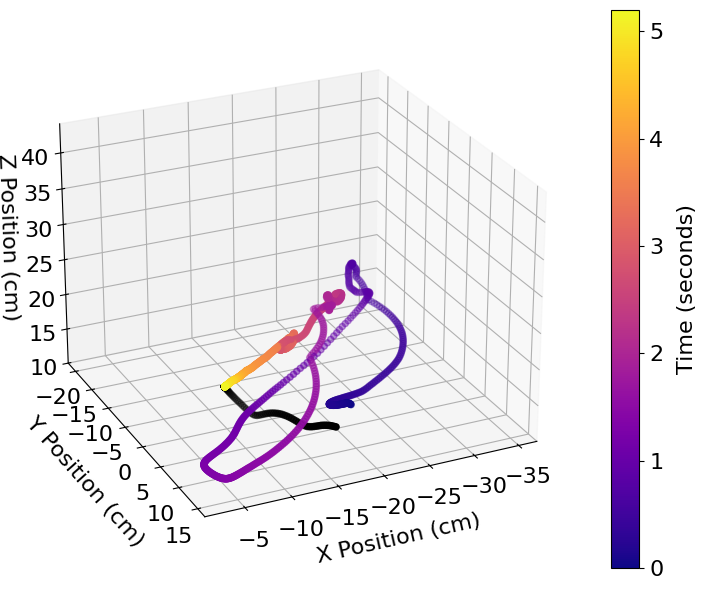

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # for 3D plotting

# === Load the Data ===
test4 = "https://docs.google.com/spreadsheets/d/e/2PACX-1vRaRzn3p7DEx40Gsx_D0ltaw6VG2lRd4NGwUobg2threpUJBXDHIhoYxcgwhWeQA3Gpf5CBD0eu4FiE/pub?gid=980275931&single=true&output=csv"
df = pd.read_csv(test4)

# === Create a 3D Plot of the Asset's Movement ===
fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection='3d')

# Plot the trajectory using X, Y, Z columns (line for overall path)
ax.plot(df['X - position'], df['Y - position'], df['Z - position'],
        linewidth=1, color='white', zorder=1)

# Create a time axis based on 240 FPS
FPS = 240
t = np.linspace(0, len(df) / FPS, len(df))  # time in seconds

# Choose a colormap for the time-based coloring
cmap = plt.cm.plasma  # options: plasma, viridis, inferno, magma, etc.

# Create masks for motor on and motor off points
mask_before_2 = t < 5.2
mask_after_2 = t >= 5.2

# Plot scatter for points before 2 seconds using the colormap
sc1 = ax.scatter(df.loc[mask_before_2, 'X - position'],
                 df.loc[mask_before_2, 'Y - position'],
                 df.loc[mask_before_2, 'Z - position'],
                 c=t[mask_before_2], cmap=cmap, marker='o', zorder=3) # , label='Motors on'

# Plot scatter for points after 2 seconds using a constant color (e.g., red)
sc2 = ax.scatter(df.loc[mask_after_2, 'X - position'],
                 df.loc[mask_after_2, 'Y - position'],
                 df.loc[mask_after_2, 'Z - position'],
                 color='black', marker='o', zorder=3, label='Motors turned off')

# Add a colorbar for the colormap-based points
cbar = plt.colorbar(sc1, ax=ax, label='Time (seconds)')
cbar.ax.tick_params(labelsize=16)
cbar.set_label('Time (seconds)', fontsize=16, labelpad=10)

# Adjust the viewing angle (elevation and azimuth)
ax.view_init(elev=25, azim=65)

# Set plot titles and labels
#ax.set_title('3D Asset Movement over Time')
ax.tick_params(labelsize=16)
ax.set_xlabel('X Position (cm)', fontsize=16, labelpad=10)
ax.set_ylabel('Y Position (cm)', fontsize=16, labelpad=10)
ax.set_zlabel('Z Position (cm)', fontsize=16, labelpad=5)
ax.set_zlim(10, 44)  # Set Z-position y-axis range
#ax.legend()
plt.tight_layout()
plt.show()

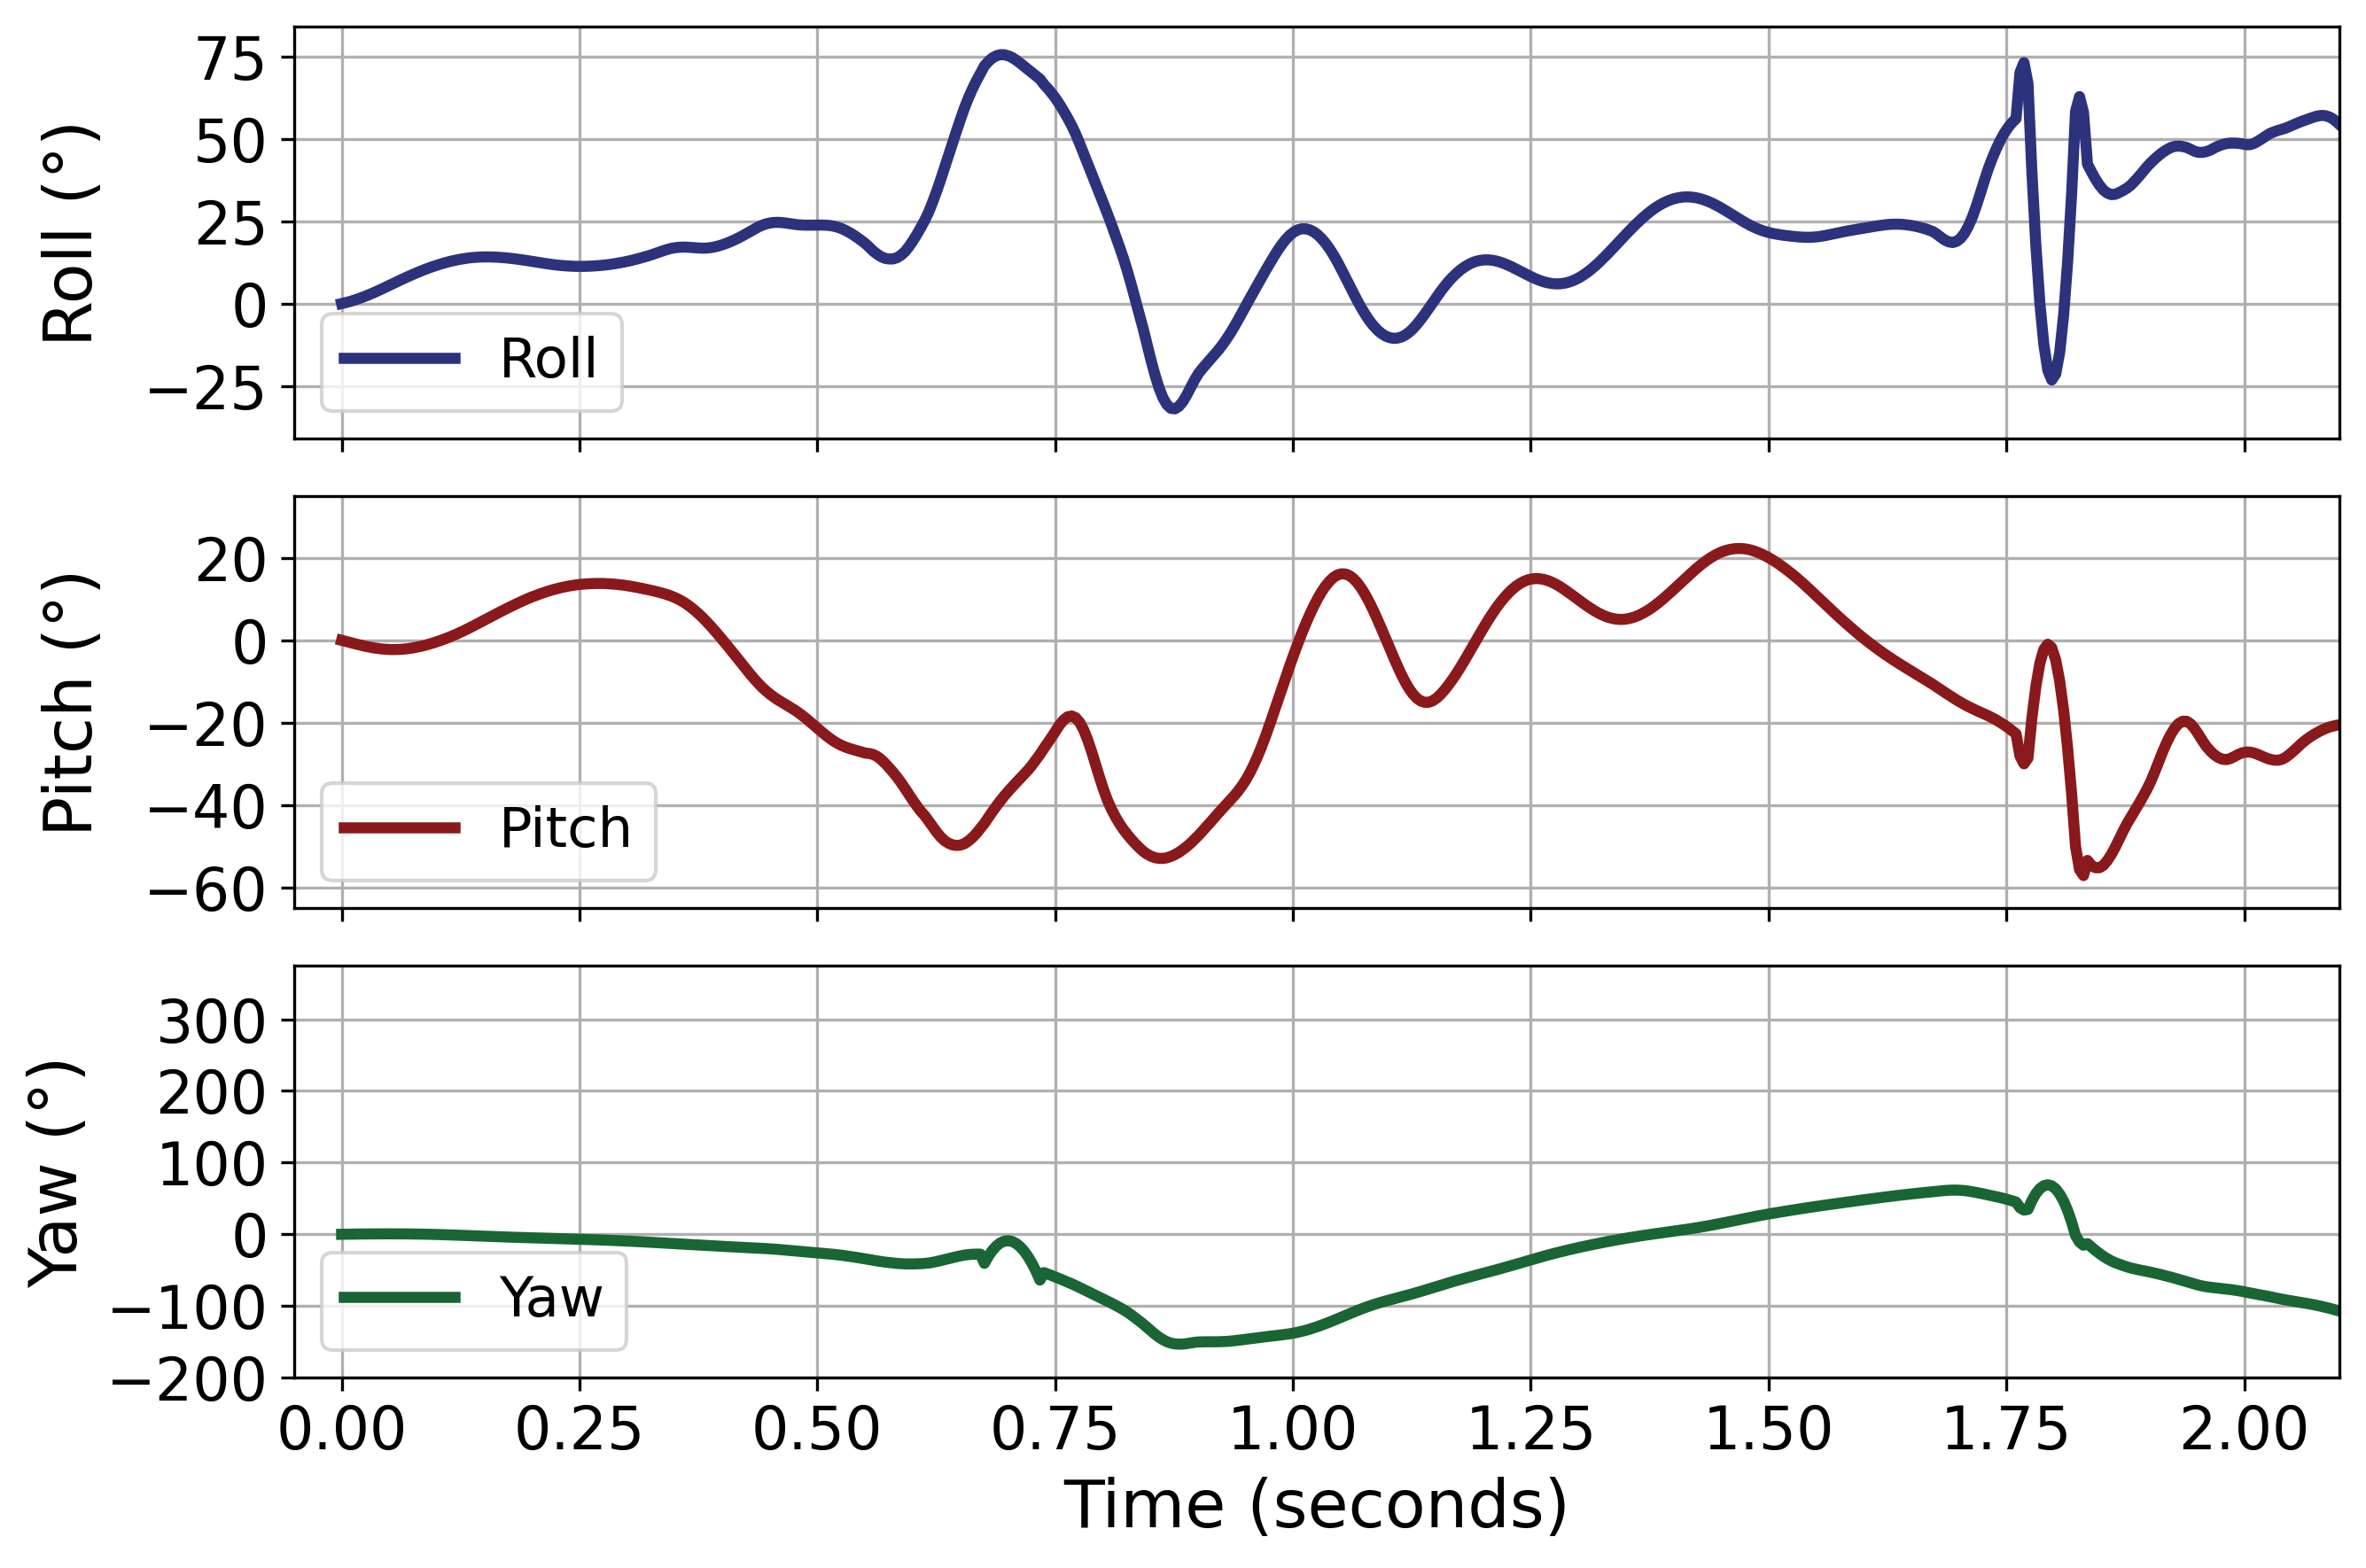

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, find_peaks
import math

# === Global Constants ===
G_PROMINENCE = 0.05
G_DISTANCE = 100
G_AXIS = 'Roll'
G_VIEW = 1000
FPS = 240

# === Data Start Variable ===
# Set this to a custom starting index, or use None to auto-detect the start.
data_start = 5 # None

# === Y-Axis Displacement Variables ===
roll_disp = 0      # Displacement for Roll (in degrees)
pitch_disp = 0      # Displacement for Pitch (in degrees)
yaw_disp = 0       # Displacement for Yaw (in degrees)

# === Helper Functions ===
def toDegrees(rad):
    return rad * 180 / math.pi

def euler_from_quaternion(x, y, z, w):
    """
    Convert a quaternion (x, y, z, w) to Euler angles (roll, pitch, yaw)
    using the Tait-Bryan angles (rotation order ZYX). The angles are returned in degrees.
    """
    # Compute Roll (x-axis rotation)
    sinr_cosp = 2.0 * (w * x + y * z)
    cosr_cosp = 1.0 - 2.0 * (x * x + y * y)
    roll = math.atan2(sinr_cosp, cosr_cosp)

    # Compute Pitch (y-axis rotation)
    sinp = 2.0 * (w * y - z * x)
    # Clamp sinp to the range [-1, 1] to avoid numerical errors.
    if sinp > 1.0:
        sinp = 1.0
    elif sinp < -1.0:
        sinp = -1.0
    pitch = math.asin(sinp)

    # Compute Yaw (z-axis rotation)
    siny_cosp = 2.0 * (w * z + x * y)
    cosy_cosp = 1.0 - 2.0 * (y * y + z * z)
    yaw = math.atan2(siny_cosp, cosy_cosp)

    return math.degrees(roll) * -1, math.degrees(pitch) * 1, math.degrees(yaw) * 1

def smooth_signal(signal, window_length=15, polyorder=3):
    return savgol_filter(signal, window_length, polyorder)

def process_euler(df, custom_start=None):
    # Convert quaternion columns to Euler angles.
    euler_angles = df.apply(
        lambda row: euler_from_quaternion(
            row['X - rotation'], row['Y - rotation'], row['Z - rotation'], row['W - rotation']
        ),
        axis=1
    )
    euler_df = pd.DataFrame(euler_angles.tolist(), columns=['Roll', 'Pitch', 'Yaw'])

    # Smooth each Euler angle signal.
    for axis in ['Roll', 'Pitch']: # , 'Yaw'
        euler_df[axis] = smooth_signal(euler_df[axis])

    # Auto-detect starting index using peaks in the Roll signal.
    peak_indices, _ = find_peaks(euler_df[G_AXIS], height=0, distance=G_DISTANCE, prominence=G_PROMINENCE)
    start_peak_idx = None
    for i in range(1, len(peak_indices)):
        if abs(euler_df[G_AXIS].iloc[peak_indices[i]] - euler_df[G_AXIS].iloc[peak_indices[i - 1]]) > 50:
            start_peak_idx = peak_indices[i - 1]
            break

    if custom_start is not None:
        start = custom_start
    else:
        start = max((start_peak_idx if start_peak_idx is not None else 0), 5)
    end = start + G_VIEW
    return euler_df.iloc[start - 5:end].reset_index(drop=True)

def trim_by_degree_change(euler_df, threshold=10):
    roll = euler_df['Roll'].values
    for i in range(1, len(roll)):
        if abs(roll[i] - roll[i - 1]) < threshold:
            return euler_df.iloc[i:].reset_index(drop=True)
    return euler_df

# === Load and Process a Single Dataset ===
url = "https://docs.google.com/spreadsheets/d/e/2PACX-1vRaRzn3p7DEx40Gsx_D0ltaw6VG2lRd4NGwUobg2threpUJBXDHIhoYxcgwhWeQA3Gpf5CBD0eu4FiE/pub?gid=980275931&single=true&output=csv"
df = pd.read_csv(url)

# Process the Euler angles using the data_start variable.
euler_df = process_euler(df, custom_start=data_start)
euler_df_trimmed = euler_df  # or use trim_by_degree_change(euler_df) if desired

# Unwrap the yaw angles to remove the jump from -180/180°.
euler_df_trimmed['Yaw'] = np.rad2deg(np.unwrap(np.deg2rad(euler_df_trimmed['Yaw'])))
euler_df_trimmed['Yaw'] = smooth_signal(euler_df_trimmed['Yaw'])

# Recalibrate each series so the initial point is 0 degrees
euler_df_trimmed['Roll'] = euler_df_trimmed['Roll'] - euler_df_trimmed['Roll'][0]
euler_df_trimmed['Pitch'] = euler_df_trimmed['Pitch'] - euler_df_trimmed['Pitch'][0]
euler_df_trimmed['Yaw'] = euler_df_trimmed['Yaw'] - euler_df_trimmed['Yaw'][0]

# Create the time axis.
time_axis = np.linspace(0, len(euler_df_trimmed) / FPS, len(euler_df_trimmed))

# === Plotting Roll, Pitch, and Yaw on Separate Axes ===
fig, axs = plt.subplots(3, 1, figsize=(9, 6), dpi=300, sharex=True)

# Plot Roll with displacement.
axs[0].plot(time_axis, euler_df_trimmed['Roll'] + roll_disp, color='#2c327b', linewidth=3)
axs[0].set_ylabel('Roll (°)', fontsize=18, labelpad=10)
axs[0].grid(True)
axs[0].tick_params(labelsize=16)
axs[0].legend(['Roll'], loc='lower left', fontsize=15)
axs[0].set_xlim(-0.05, 2.1)  # Set Roll x-axis range
axs[0].set_ylim(-41, 84)  # Set Roll y-axis range
axs[0].set_yticks(np.arange(-25, 84, 25))

# Plot Pitch with displacement.
axs[1].plot(time_axis, euler_df_trimmed['Pitch'] + pitch_disp, color='#8a191b', linewidth=3)
axs[1].set_ylabel('Pitch (°)', fontsize=18, labelpad=10)
axs[1].grid(True)
axs[1].tick_params(labelsize=16)
axs[1].legend(['Pitch'], loc='lower left', fontsize=15)
axs[1].set_xlim(-0.05, 2.1)  # Set Pitch x-axis range
axs[1].set_ylim(-65, 35)  # Set Pitch y-axis range
axs[1].set_yticks(np.arange(-60, 25, 20))

# Plot Yaw with displacement.
axs[2].plot(time_axis, euler_df_trimmed['Yaw'] + yaw_disp, color='#196534', linewidth=3)
axs[2].set_ylabel('Yaw (°)', fontsize=18)
axs[2].set_xlabel('Time (seconds)', fontsize=18)
axs[2].grid(True)
axs[2].tick_params(labelsize=16)
axs[2].legend(['Yaw'], loc='lower left', fontsize=15)
axs[2].set_xlim(-0.05, 2.1)  # Set Yaw x-axis range
axs[2].set_ylim(-200, 375)  # Set Yaw y-axis range
axs[2].set_yticks(np.arange(-200, 375, 100))
plt.tight_layout()
plt.show()

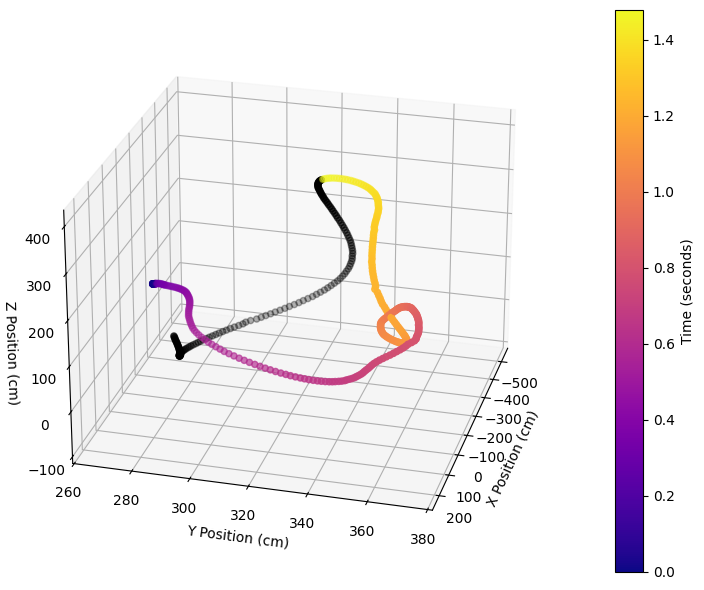

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # for 3D plotting

# === Load the Data ===
test4 = "https://docs.google.com/spreadsheets/d/e/2PACX-1vRaRzn3p7DEx40Gsx_D0ltaw6VG2lRd4NGwUobg2threpUJBXDHIhoYxcgwhWeQA3Gpf5CBD0eu4FiE/pub?gid=1432879181&single=true&output=csv"
df = pd.read_csv(test4)

# === Create a 3D Plot of the Asset's Movement ===
fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection='3d')

# Plot the trajectory using X, Y, Z columns (line for overall path)
ax.plot(df['X - position'], df['Y - position'], df['Z - position'],
        linewidth=1, color='white', zorder=1)

# Create a time axis based on 240 FPS
FPS = 240
t = np.linspace(0, len(df) / FPS, len(df))  # time in seconds

# Choose a colormap for the time-based coloring
cmap = plt.cm.plasma  # options: plasma, viridis, inferno, magma, etc.

# Create masks for motor on and motor off points
mask_before_2 = t < 1.48
mask_after_2 = t >= 1.48

# Plot scatter for points before 2 seconds using the colormap
sc1 = ax.scatter(df.loc[mask_before_2, 'X - position'],
                 df.loc[mask_before_2, 'Y - position'],
                 df.loc[mask_before_2, 'Z - position'],
                 c=t[mask_before_2], cmap=cmap, marker='o', zorder=3) # , label='Motors on'

# Plot scatter for points after 2 seconds using a constant color (e.g., red)
sc2 = ax.scatter(df.loc[mask_after_2, 'X - position'],
                 df.loc[mask_after_2, 'Y - position'],
                 df.loc[mask_after_2, 'Z - position'],
                 color='black', marker='o', zorder=3, label='Motors turned off')

# Add a colorbar for the colormap-based points
plt.colorbar(sc1, ax=ax, label='Time (seconds)')

# Adjust the viewing angle (elevation and azimuth)
ax.view_init(elev=25, azim=15)

# Set plot titles and labels
#ax.set_title('3D Asset Movement over Time')
ax.set_xlabel('X Position (cm)')
ax.set_ylabel('Y Position (cm)')
ax.set_zlabel('Z Position (cm)')
#ax.legend()
plt.tight_layout()
plt.show()